In [2]:
# ==============================================================================
# ETAPA 1: IMPORTAR AS FERRAMENTAS (BIBLIOTECAS)
# ==============================================================================
# Aqui nós estamos chamando os "ajudantes" do Python. Cada um tem uma especialidade.
import pandas as pd  # O Pandas serve para criar e mexer em tabelas (como se fosse o Excel da TI).
import numpy as np  # O Numpy serve para fazer contas matemáticas e gerar números de forma inteligente.

# ==============================================================================
# ETAPA 2: CONFIGURAR A CRIAÇÃO DOS DADOS SIMULADOS
# ==============================================================================
# "Seed" significa semente. Definir um número aqui garante que, toda vez que você
# rodar esse código, ele vai gerar exatamente os mesmos números aleatórios.
np.random.seed(42)

# Definimos que o nosso banco fictício terá uma base inicial de 1.000 clientes
n_clientes = 1000

# Criamos um dicionário (uma lista de informações) com as colunas que um banco real usa:
dados = {
    'id_cliente': range(
        1001, 1001 + n_clientes
    ),  # Cria um número de identificação para cada cliente (ex: 1001, 1002...)
    'idade': np.random.randint(
        18, 70, size=n_clientes
    ),  # Gera idades misturadas entre 18 e 70 anos.
    'renda_anual': np.random.randint(
        20000, 150000, size=n_clientes
    ),  # Gera rendas anuais variando de R$ 20 mil a R$ 150 emil.
    'score_credito': np.random.randint(
        300, 850, size=n_clientes
    ),  # Gera a nota de bom pagador (Score do Serasa) entre 300 e 850.
    'valor_emprestimo': np.random.randint(
        5000, 60000, size=n_clientes
    ),  # Gera o valor em dinheiro que o cliente pediu emprestado (R$ 5 mil a R$ 60 mil).
}

# Aqui nós transformamos essa lista de informações em uma TABELA visual (chamada de DataFrame ou 'df')
df = pd.DataFrame(dados)

# ==============================================================================
# ETAPA 3: A REGRA DE NEGÓCIO DO BANCO (QUEM TEM CHANCE DE DAR CALOTE?)
# ==============================================================================
# Agora criamos uma lógica matemática realista para o computador entender o risco.
# A chance de risco aumenta se o Score do cliente for baixo E se o empréstimo for muito pesado para a renda dele.
probabilidade_risco = ((850 - df['score_credito']) / 550 * 0.5) + (
    (df['valor_emprestimo'] / df['renda_anual']) * 0.4
)

# Adicionamos uma "imprevisto do mercado" (desemprego, inflação, etc.) para os dados não ficarem perfeitos demais.
probabilidade_risco += np.random.normal(0, 0.1, n_clientes)

# Garantimos que a chance de risco fique matematicamente travada entre 0 (0% de chance) e 1 (100% de chance).
probabilidade_risco = np.clip(probabilidade_risco, 0, 1)

# Se o cálculo final disser que o cliente tem mais de 50% (0.5) de chance de dar calote,
# a gente carimba ele como "Inadimplente" (Número 1). Se for seguro, vira (Número 0).
df['inadimplente'] = (probabilidade_risco > 0.5).astype(int)

# ==============================================================================
# ETAPA 4: SALVAR O TRABALHO E MOSTRAR O RESULTADO
# ==============================================================================
# Pega essa tabela prontinha e salva em um arquivo de computador chamado 'dados_credito_banco.csv'
df.to_csv('dados_credito_banco.csv', index=False)

# Imprime na tela o relatório final para o usuário ver que deu tudo certo
print("Base de dados bancários gerada e salva com sucesso!")
print(f"Total de clientes gerados: {len(df)}")
print(f"Quantidade de inadimplentes na base: {df['inadimplente'].sum()}")

Base de dados bancários gerada e salva com sucesso!
Total de clientes gerados: 1000
Quantidade de inadimplentes na base: 388


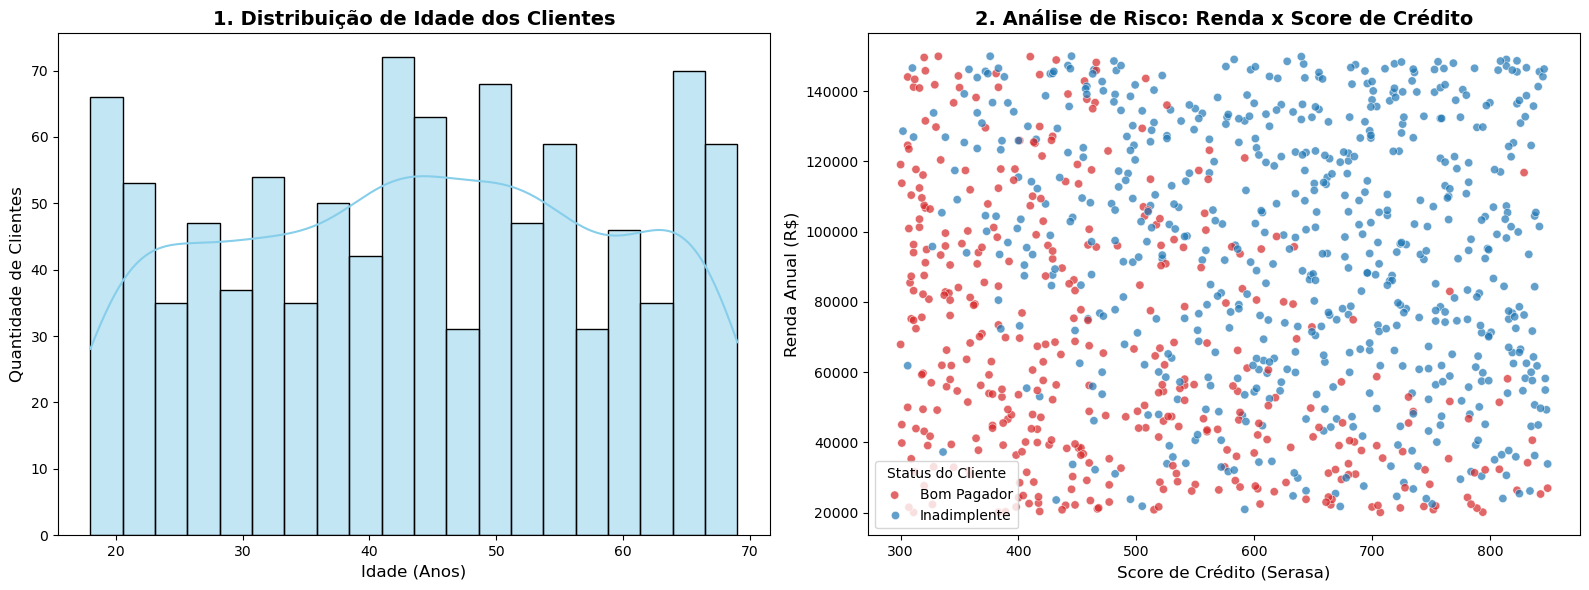

In [6]:
# ==============================================================================
# ETAPA 2: ANALISAR OS DADOS VISUALMENTE (GERAR GRÁFICOS) - CORRIGIDO
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carregamos o arquivo que salvamos na etapa anterior
df_banco = pd.read_csv('dados_credito_banco.csv')

# Configuramos o ambiente para mostrar 2 gráficos, um do lado do outro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------------------
# GRÁFICO 1: Quem são as pessoas na nossa base? (Distribuição de Idade)
# ------------------------------------------------------------------------------
sns.histplot(df_banco['idade'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1. Distribuição de Idade dos Clientes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade (Anos)', fontsize=12)
axes[0].set_ylabel('Quantidade de Clientes', fontsize=12)

# ------------------------------------------------------------------------------
# GRÁFICO 2: Onde estão os inadimplentes? (Renda x Score de Crédito)
# ------------------------------------------------------------------------------
sns.scatterplot(
    x='score_credito', 
    y='renda_anual', 
    hue='inadimplente', 
    data=df_banco, 
    palette={0: '#1f77b4', 1: '#d62728'}, 
    alpha=0.7, 
    ax=axes[1]
)
axes[1].set_title('2. Análise de Risco: Renda x Score de Crédito', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score de Crédito (Serasa)', fontsize=12)
axes[1].set_ylabel('Renda Anual (R$)', fontsize=12)

# AQUI ESTAVA O ERRO: O comando correto para o objeto 'axes' é apenas .legend()
axes[1].legend(title='Status do Cliente', labels=['Bom Pagador', 'Inadimplente'])

# Ajusta o espaçamento para os gráficos não ficarem espremidos
plt.tight_layout()

# Mostra os gráficos na tela
plt.show()

In [8]:
# ==============================================================================
# ETAPA 3: ENGENHARIA DE RECURSOS (CRIAR VARIÁVEIS INTELIGENTES)
# ==============================================================================
# Criamos uma nova coluna chamada 'proporcao_parcela'.
# Ela divide o valor do empréstimo pela renda anual para ver o tamanho do impacto financeiro.
df_banco['proporcao_parcela'] = df_banco['valor_emprestimo'] / df_banco['renda_anual']

# Exibe as primeiras 5 linhas da tabela para a gente validar se a nova coluna foi criada
print("Nova variável criada com sucesso! Veja as primeiras linhas da tabela:")
df_banco[['id_cliente', 'renda_anual', 'valor_emprestimo', 'proporcao_parcela', 'inadimplente']].head()

Nova variável criada com sucesso! Veja as primeiras linhas da tabela:


,id_cliente,renda_anual,valor_emprestimo,proporcao_parcela,inadimplente
0,1001,125186,12239,0.097767,1
1,1002,54674,11710,0.214179,0
2,1003,55854,26384,0.472374,1
3,1004,66271,26038,0.392902,1
4,1005,93688,45846,0.489348,1


In [10]:
# ==============================================================================
# ETAPA 4: TREINAR A INTELIGÊNCIA ARTIFICIAL (MACHINE LEARNING)
# ==============================================================================
# Importamos as ferramentas do Scikit-Learn (a biblioteca padrão de IA no Python)
from sklearn.model_selection import train_test_split  # Serve para dividir os dados em treino e teste
from sklearn.ensemble import RandomForestClassifier  # O algoritmo de Inteligência Artificial
from sklearn.metrics import accuracy_score, classification_report  # Servem para medir o sucesso da IA

# 1. SEPARAÇÃO: Dizemos para o computador o que são as características do cliente (X) e o que é o resultado (y)
# Tiramos o 'id_cliente' porque o número do ID não ajuda a prever calote, e tiramos a resposta final.
X = df_banco.drop(columns=['id_cliente', 'inadimplente'])
y = df_banco['inadimplente']

# 2. DIVISÃO DE TREINO E TESTE: Separamos 80% dos clientes para a IA estudar (treinar) 
# e guardamos 20% em segredo para testar se ela aprendeu a prever de verdade.
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. CRIAÇÃO DO MODELO: Inicializamos a máquina de IA (a nossa Floresta Aleatória)
modelo_banco = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. TREINAMENTO: A IA lê os dados de treino e começa a descobrir os padrões de risco sozinha
modelo_banco.fit(X_treino, y_treino)

# 5. TESTE: Pedimos para a IA tentar adivinhar a situação daqueles 20% de clientes que guardamos em segredo
previsoes = modelo_banco.predict(X_teste)

# 6. RESULTADO: Calculamos a porcentagem de acerto da IA
acuracia = accuracy_score(y_teste, previsoes)

print("=== TREINAMENTO CONCLUÍDO COM SUCESSO! ===")
print(f"Acurácia do Modelo (Porcentagem de acerto): {acuracia * 100:.2f}%")
print("\nRelatório de Performance Técnico para o RH:")
print(classification_report(y_teste, previsoes, target_names=['Bom Pagador', 'Inadimplente']))

=== TREINAMENTO CONCLUÍDO COM SUCESSO! ===
Acurácia do Modelo (Porcentagem de acerto): 85.50%

Relatório de Performance Técnico para o RH:
              precision    recall  f1-score   support

 Bom Pagador       0.85      0.91      0.88       117
Inadimplente       0.86      0.77      0.82        83

    accuracy                           0.85       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.86      0.85      0.85       200



In [12]:
# ==============================================================================
# ETAPA 5: TRADUZINDO O CÓDIGO EM DINHEIRO SALVO PARA O BANCO
# ==============================================================================
# Vamos fazer uma conta rápida: imagine que cada calote custe em média R$ 25.000 para o banco.
custo_por_calote = 25000

# Descobrimos quantos calotes a nossa Inteligência Artificial conseguiu evitar no grupo de teste
calotes_evitados = sum((y_teste == 1) & (previsoes == 1))

# Calculamos o montante total de prejuízo que o banco economizou graças ao seu código
dinheiro_salvo = calotes_evitados * custo_por_calote

print("=== RELATÓRIO DE IMPACTO FINANCEIRO DO PROJETO ===")
print(f"Total de calotes reais que estavam escondidos no teste: {sum(y_teste == 1)}")
print(f"Calotes que a nossa IA detectou e bloqueou a tempo: {calotes_evitados}")
print(f"💰 Prejuízo evitado para os cofres do banco: R$ {dinheiro_salvo:,.2f}".replace(",", "."))

=== RELATÓRIO DE IMPACTO FINANCEIRO DO PROJETO ===
Total de calotes reais que estavam escondidos no teste: 83
Calotes que a nossa IA detectou e bloqueou a tempo: 64
💰 Prejuízo evitado para os cofres do banco: R$ 1.600.000.00
